In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import plotnine as p9
import liana as li
import muon as mu
import anndata as ad
import matplotlib.pyplot as plt
import squidpy as sq
from liana.method._pipe_utils._common import _get_props
from liana.method.sp._utils import _add_complexes_to_var
from liana._logging import _logg
from liana.method._pipe_utils import prep_check_adata, assert_covered
from scipy.sparse import csr_matrix
from pathlib import Path

/home/alsayah/.local/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
/home/alsayah/.local/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/home/alsayah/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.


In [ ]:
#Xeinum
#genes = pd.read_csv("/g/stegle/aalsayah/repos/data/xenium/ziniom_genes.csv")

In [55]:
slide_tag = Path("/g/stegle/aalsayah/repos/data/slidatag")

In [81]:
merfish_path = Path("/g/stegle/aalsayah/repos/data/merfish")

In [2]:
xeinum_path = Path("/g/stegle/aalsayah/repos/data/xenium")

In [2]:
visium_path = Path("/g/stegle/aalsayah/repos/data/visiumHD")

In [ ]:
seqFISH_path = Path("/g/stegle/aalsayah/repos/data/seqFISH")

In [4]:
#adata = sc.read(merfish_path / "adata_healthy_diseased_merfish_.h5ad")

In [5]:
#adata = sc.read(merfish_path / "Breast_data/merfish.h5ad")

In [3]:
adata = sc.read(xeinum_path / "skin_adata.h5ad")

In [ ]:
adata = sc.read(seqFISH_path / "ziniom.h5ad")

In [ ]:
adata = sc.read(visium_path / "CRC/Visium_HD_Human_Colon_Cancer_P1_molecule_info.h5")

In [ ]:
adata

AnnData object with n_obs × n_vars = 104276 × 4278
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'n_counts', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mean', 'std'
    uns: 'dendrogram_leiden', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'lognorm'
    obsp: 'connectivities', 'distances'

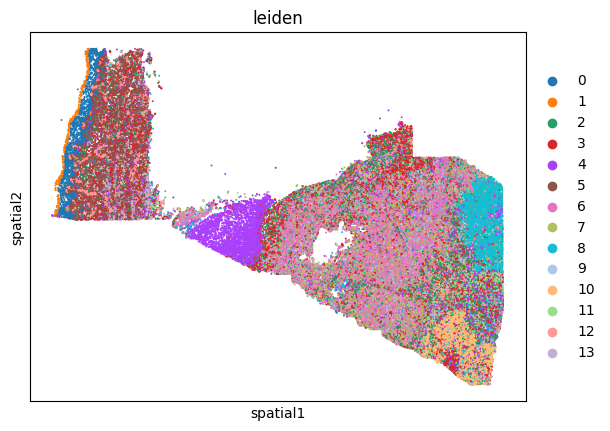

In [5]:
sc.pl.embedding(adata, basis="spatial", color="leiden", s=8)  # s = point size

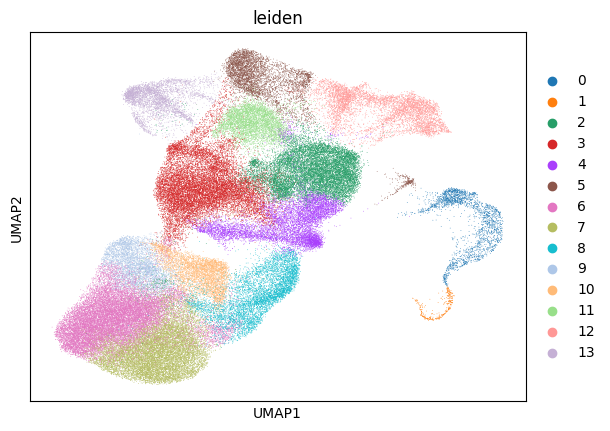

In [6]:
# Visualize on UMAP
sc.pl.umap(adata, color=["leiden"])

In [ ]:
# 2) dimensionality reduction for the graph (PCA is typical)
sc.tl.pca(adata, svd_solver="arpack", n_comps=50)

# 3) neighbors graph (drives UMAP)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)  # tune n_neighbors/n_pcs

# 4) UMAP
sc.tl.umap(adata, min_dist=0.5, random_state=0)

# Visualize on UMAP
sc.pl.umap(adata, color=["cell_type"])

In [60]:
fine_to_broad = {
    'Neuron-1': 'Neuron',
    'Neuron-2': 'Neuron',
    'Neuron-3': 'Neuron',
    'Neuron-4': 'Neuron',
    'Neuron-5': 'Neuron',
    'Neuron-6': 'Neuron',
    'Neuron-7': 'Neuron',
    'Neuron-8': 'Neuron',
    'Neuron-9': 'Neuron',
    'Neuron-10': 'Neuron',
    'Neuron-11': 'Neuron',
    'Neuron-12': 'Neuron',
    'Neuron-13': 'Neuron',
    'Neuron-14': 'Neuron',
    'Neuron-15': 'Neuron',
    'Neuron-16': 'Neuron',
    'Radial glia': 'Glial',
    'White Blood Cells': 'Immune',
    'Endothelial': 'Endothelial',
    'Fibroblast': 'Fibroblast',
    'Choroid Plexus': 'Choroid Plexus'
}

In [61]:
adata.obs["cell_type_lv1"] =  adata.obs['cell_type'].map(fine_to_broad)

... storing 'cell_type_lv1' as categorical


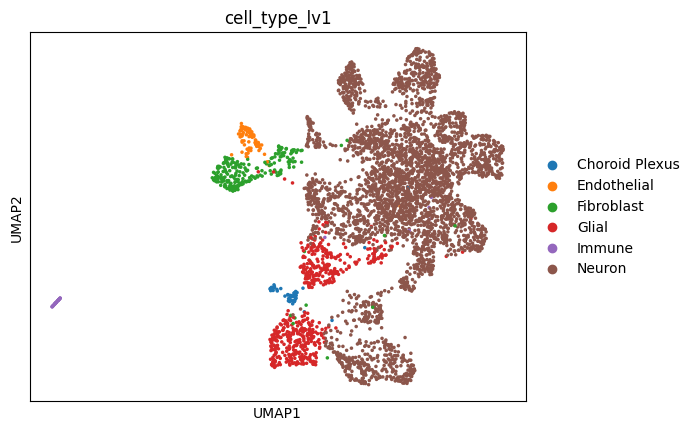

In [62]:
# Visualize on UMAP
sc.pl.umap(adata, color=["cell_type_lv1"])

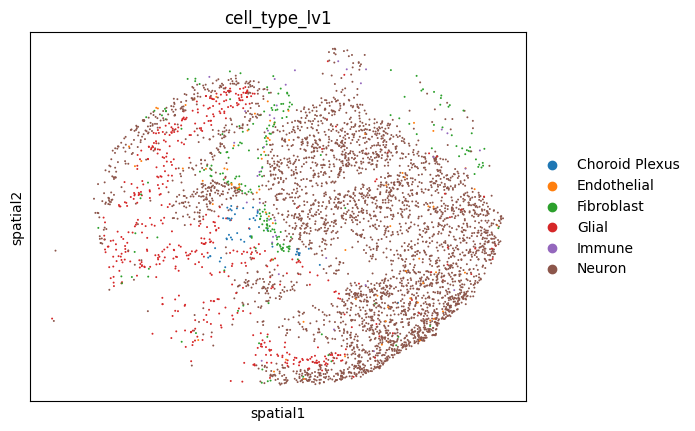

In [63]:
sc.pl.embedding(adata, basis="spatial", color="cell_type_lv1", s=8)  # s = point size

In [ ]:
import scanpy as sc

# optional: ensures points are rasterized automatically when saving vector formats (PDF/SVG)
sc.settings.set_figure_params(vector_friendly=True)

sc.pl.umap(
    adata,
    color=['cell_type'],
    size=2,
    wspace=0.3,
    ncols=2,
    frameon=False,
    # rasterized=True  # <-- remove this
)


### Check LR genes

In [11]:
lr = li.rs.select_resource('consensus')

### Mouse

In [19]:
map_df = li.rs.get_hcop_orthologs(url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_mouse_hcop_fifteen_column.txt.gz',
                                  columns=['human_symbol', 'mouse_symbol'],
                                   # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                   min_evidence=3
                                   )

/g/stegle/aalsayah/repos/liana-py/liana/resource/_orthology.py:199: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


In [20]:
map_df

,human_symbol,mouse_symbol
85,-,Bbs1
86,-,Tm9sf1
87,-,Ddx19b
88,-,Oc90
89,-,Vamp2
...,...,...
68073,ZYG11A,Zyg11a
68075,ZYG11B,Zyg11b
68077,ZYX,Zyx
68078,ZZEF1,Zzef1


In [21]:
# rename the columns to source and target, respectively for the original organism and the target organism
map_df = map_df.rename(columns={'human_symbol':'source', 'mouse_symbol':'target'})

In [22]:
# We will then translate
mouse = li.rs.translate_resource(resource,
                                 map_df=map_df,
                                 columns=['ligand', 'receptor'],
                                 replace=True,
                                 # Here, we will be harsher and only keep mappings that don't map to more than 1 mouse gene
                                 one_to_many=1
                                 )
mouse

,ligand,receptor
0,Lgals9,Ptprc
1,Lgals9,Met
2,Lgals9,Cd44
3,Lgals9,Lrp1
4,Lgals9,Cd47
...,...,...
4619,Bmp2,Actr2
4620,Bmp15,Actr2
4621,Csf1,Csf3r
4622,Il36g,Ifnar1


In [31]:
# Suppose df has columns col1 and col2
mouse.tuples = list(zip(mouse["ligand"], mouse["receptor"]))

/scratch/jobs/38195810/ipykernel_380227/3446814065.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access


In [68]:
#retrive LR database
lr = li.rs.select_resource()
ligand_set = set(lr['ligand']) #1027
receptor_set = set(lr['receptor']) #1052

### Human

In [7]:
genes = adata.var_names

In [12]:
# Convert gene list to a set for fast lookup
gene_set = set(genes)

# Filter lr_df where both ligand and receptor are in the gene list
possible_interactions = lr[
    lr['ligand'].isin(gene_set) & lr['receptor'].isin(gene_set)
]


# Get the count
interaction_count = possible_interactions.shape[0]

print(f"Number of possible interactions: {interaction_count}")


Number of possible interactions: 967


### Mouse

In [ ]:
# Convert gene list to a set for fast lookup
gene_set = set(genes)

# Filter lr_df where both ligand and receptor are in the gene list
possible_interactions = lr[
    mouse['ligand'].isin(gene_set) & mouse['receptor'].isin(gene_set)
]


# Get the count
interaction_count = possible_interactions.shape[0]

print(f"Number of possible interactions: {interaction_count}")


Number of possible interactions: 820


### Inflow

In [14]:
adata

AnnData object with n_obs × n_vars = 104276 × 4278
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'n_counts', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mean', 'std'
    uns: 'dendrogram_leiden', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'lognorm'
    obsp: 'connectivities', 'distances'

In [ ]:
#Extract coords and save them in obsm["spatial"], li.ut.spatial_neighbors() and squidpy functions like sq.gr.spatial_autocorr() look for spatial coordinates in adata.obsm["spatial"] by default.
coords = adata_p1.obs[['X', 'Y']].to_numpy()
adata.obsm["spatial"] = coords

In [15]:
li.ut.spatial_neighbors(adata=adata, bandwidth=30)

In [16]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, n_jobs = 10,
                       show_progress_bar=True)

In [18]:
adata.uns['moranI']

,I,pval_norm,var_norm,pval_norm_fdr_bh
DSG1,0.805008,0.000000,3.167538e-07,0.000000
ARG1,0.757698,0.000000,3.167538e-07,0.000000
CDSN,0.697500,0.000000,3.167538e-07,0.000000
A2ML1,0.681813,0.000000,3.167538e-07,0.000000
DMKN,0.645572,0.000000,3.167538e-07,0.000000
...,...,...,...,...
KIR2DL4,-0.000683,0.115650,3.167538e-07,0.120144
CALR3,-0.000695,0.111510,3.167538e-07,0.115927
CDHR2,-0.000702,0.109159,3.167538e-07,0.113621
TRIM67,-0.000725,0.101824,3.167538e-07,0.106141


In [19]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

2071

In [20]:
adata = adata[:, svgs]

In [21]:
adata

View of AnnData object with n_obs × n_vars = 104276 × 2071
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'n_counts', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mean', 'std'
    uns: 'dendrogram_leiden', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'spatialdata_attrs', 'umap', 'moranI'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'lognorm'
    obsp: 'connectivities', 'distances', 'spatial_connectivities'

### Mouse inflow

In [ ]:
lrdata = li.mt.inflow(adata,  
                                  groupby='cell_type_lv1', # cell type columns        
                                  interactions=mouse.tuples,                          
                                  use_raw=False)
                                  
lrdata.shape

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


(4623, 5073)

### Human

In [22]:
lrdata = li.mt.inflow(adata,  
                                  groupby='leiden', # cell type columns        
                                  resource_name='cellchatdb',                        
                                  use_raw=False)
                                  
lrdata.shape

/home/alsayah/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


(104276, 2694)

In [23]:
li.mt.compute_global_score(lrdata, groupby='leiden')

/g/stegle/aalsayah/repos/liana-py/liana/method/sc/_compute_global_score.py:89: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


In [24]:
lrdata.uns["global_score"].sort_values('lr_mean').tail()

,ligand,ligand_complex,receptor,receptor_complex,source,target,lr_mean
2,JAG1,JAG1,NOTCH1,NOTCH1,0,0,1.134733
14370,CXCL12,CXCL12,ACKR3,ACKR3,5,5,1.158371
146,LAMB3,LAMB3,ITGA6,ITGB4,0,0,1.165026
2885,TGFA,TGFA,EGFR,EGFR,1,1,1.235601
2895,EREG,EREG,EGFR,EGFR,1,1,2.255443


In [25]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

In [26]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
len(svis)

2078

In [27]:
lrdata = lrdata[:, svis]

In [28]:
lrdata

View of AnnData object with n_obs × n_vars = 104276 × 2078
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'n_counts', 'leiden'
    uns: 'dendrogram_leiden', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'spatialdata_attrs', 'umap', 'moranI', 'global_score'
    obsm: 'X_pca', 'X_umap', 'spatial'
    obsp: 'connectivities', 'distances', 'spatial_connectivities'

In [29]:
lrdata.layers['transformed'] = li.utils.zi_minmax(lrdata.X, cutoff=0.01)

/scratch/jobs/38297223/ipykernel_3296819/447211400.py:1: ImplicitModificationWarning: Setting element `.layers['transformed']` of view, initializing view as actual.


# Explore LR data object

In [30]:
lrdata

AnnData object with n_obs × n_vars = 104276 × 2078
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'n_counts', 'leiden'
    uns: 'dendrogram_leiden', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'spatialdata_attrs', 'umap', 'moranI', 'global_score'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'transformed'
    obsp: 'connectivities', 'distances', 'spatial_connectivities'

In [31]:
lrdata.var_names

Index(['6^LAMC1^CD44', '10^LAMC1^CD44', '6^LAMA3^CD44', '7^LAMC1^CD44',
       '10^COL4A2^CD44', '12^SEMA4D^PLXNB2', '9^LAMC2^CD44', '6^LAMB3^CD44',
       '7^LAMA3^CD44', '10^COL4A1^CD44',
       ...
       '7^EFNB2^EPHB1', '11^DLL1^NOTCH4', '11^GZMA^F2RL1', '4^TNXB^SDC4',
       '2^FGF7^FGFR2', '10^CXCL11^CXCR3', '7^LAMA3^ITGA6_ITGB4',
       '9^SELL^PODXL', '5^GRN^SORT1', '8^CCL8^CCR1'],
      dtype='object', length=2078)

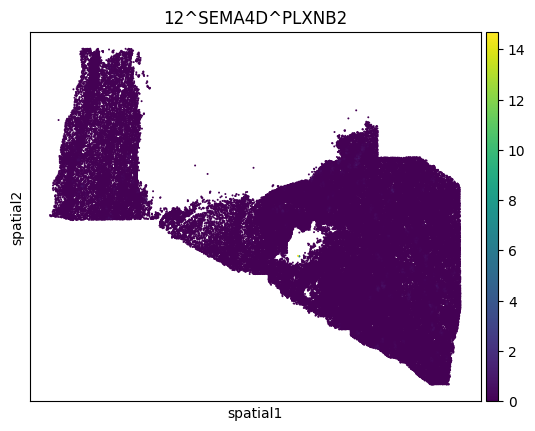

In [ ]:
sc.pl.embedding(lrdata, basis="spatial", color='12^SEMA4D^PLXNB2', s=8)  # s = point size

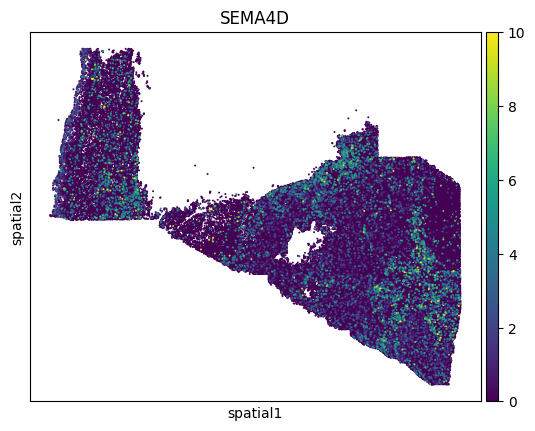

In [49]:
sc.pl.embedding(adata, basis="spatial", color='SEMA4D', s=8)  # s = point size

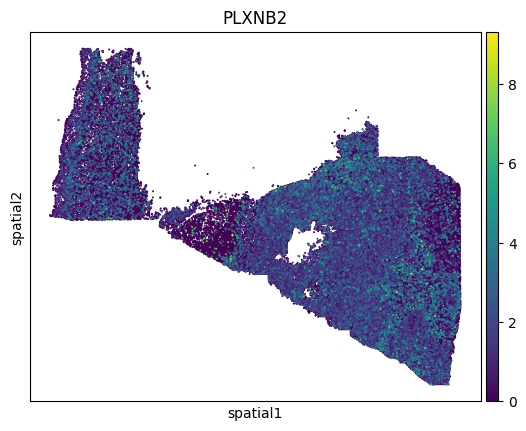

In [50]:
sc.pl.embedding(adata, basis="spatial", color='PLXNB2', s=8)  # s = point size

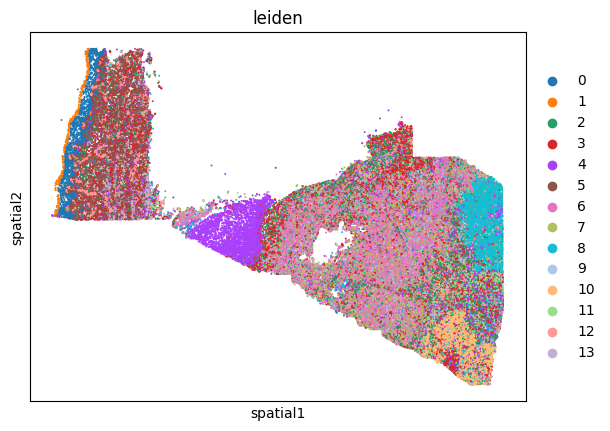

In [37]:
sc.pl.embedding(adata, basis="spatial", color='leiden', s=8)  # s = point size

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

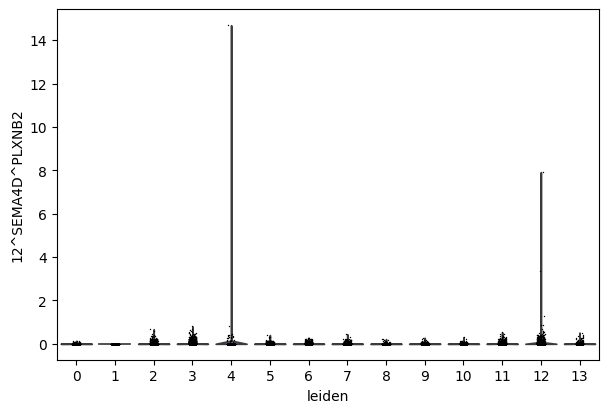

In [51]:
sc.pl.violin(lrdata, keys='12^SEMA4D^PLXNB2', groupby='leiden')

In [41]:
%%time
# PCA for dimension reduction further by UMAP for downstream analysis
sc.pp.pca(lrdata, n_comps=50)
sc.pp.neighbors(lrdata, metric="cosine")

CPU times: user 12.3 s, sys: 94.7 ms, total: 12.4 s
Wall time: 11.9 s


In [42]:
%%time
sc.tl.umap(lrdata)

CPU times: user 1min 49s, sys: 50.9 ms, total: 1min 49s
Wall time: 1min 40s


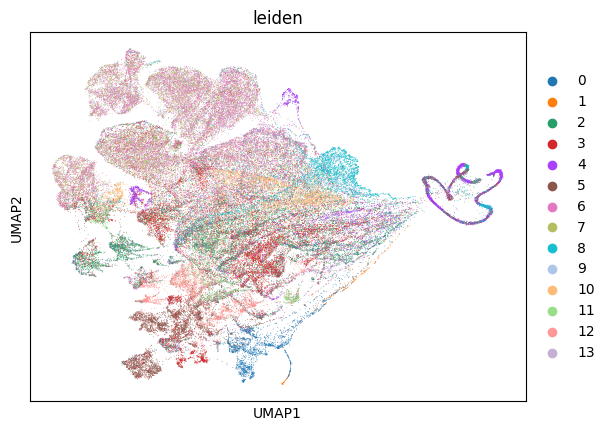

In [43]:
sc.pl.umap(lrdata, color="leiden")

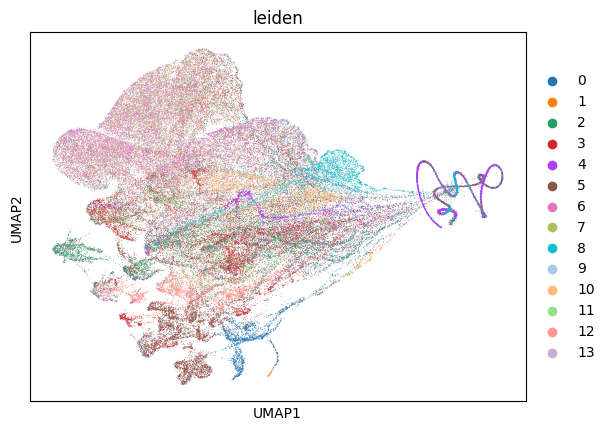

In [40]:
sc.pl.umap(lrdata, color="leiden")

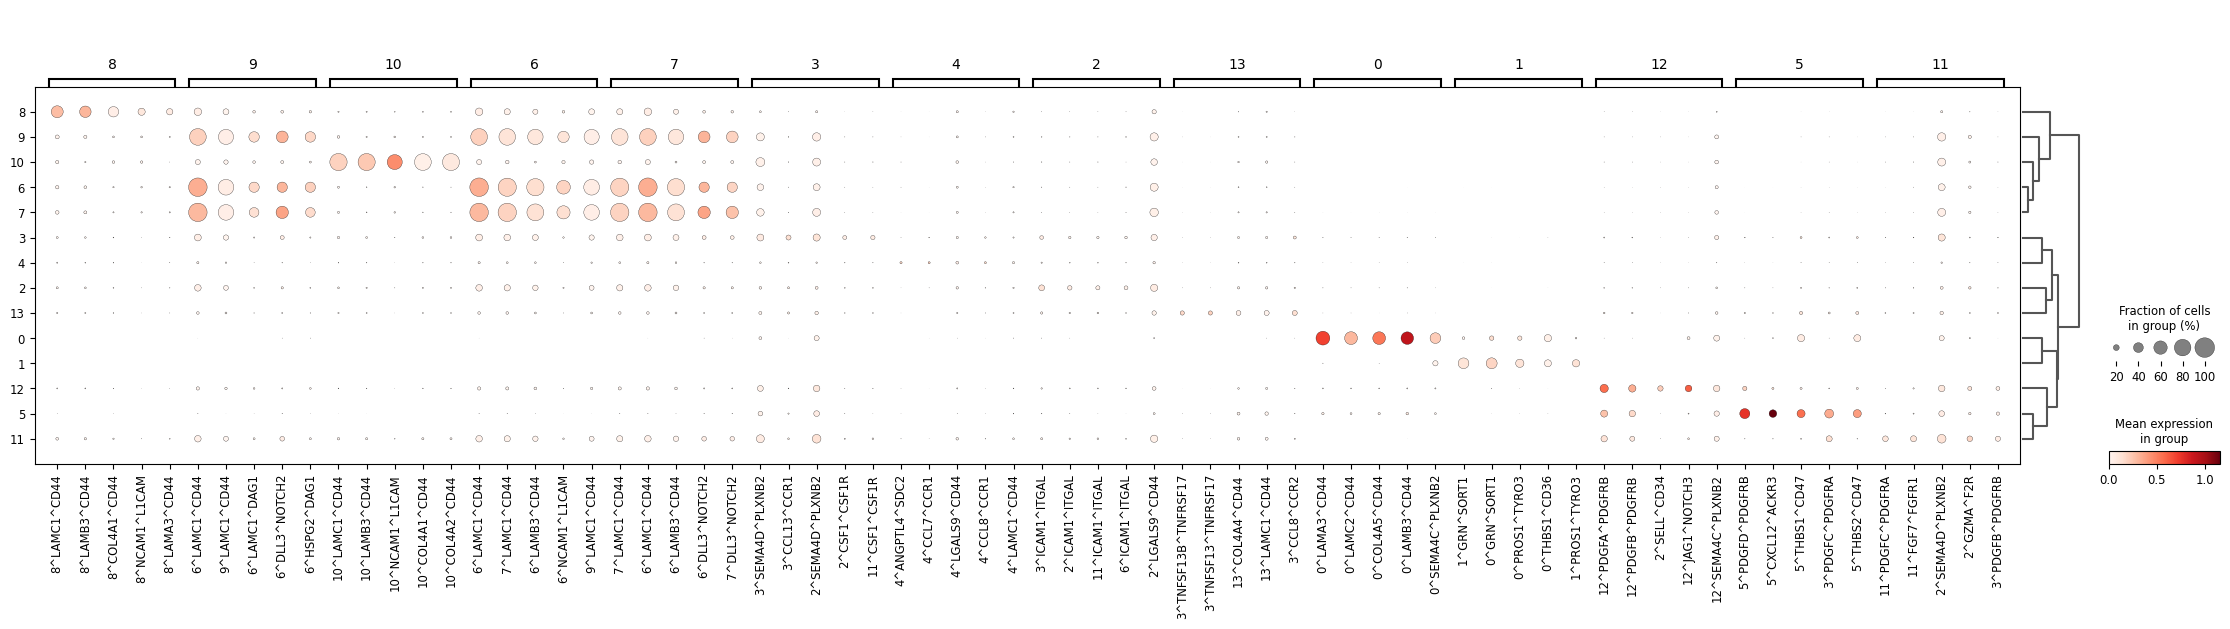

In [53]:
sc.tl.rank_genes_groups(lrdata, groupby="leiden", layer="transformed", pts=True)
sc.pl.rank_genes_groups_dotplot(lrdata, n_genes=5)

In [89]:
# 2) dimensionality reduction for the graph (PCA is typical)
sc.tl.pca(lrdata, svd_solver="arpack", n_comps=50)

# 3) neighbors graph (drives UMAP)
sc.pp.neighbors(lrdata, n_neighbors=15, n_pcs=30)  # tune n_neighbors/n_pcs

# 4) UMAP
sc.tl.umap(lrdata, min_dist=0.5, random_state=0)

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.


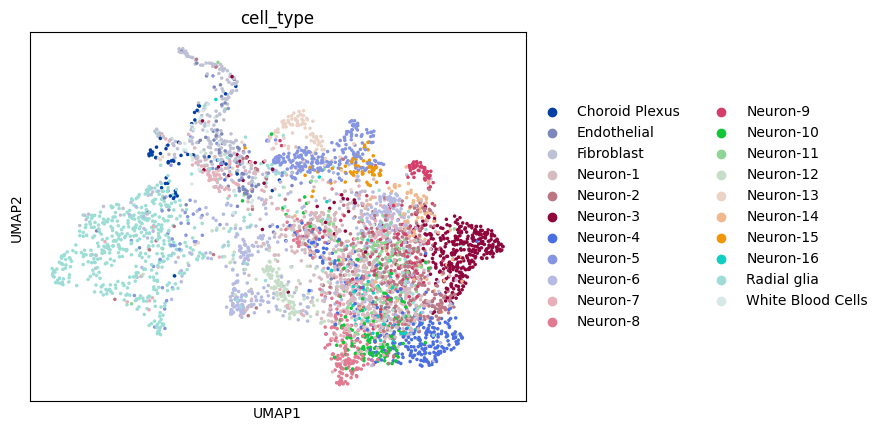

In [90]:
sc.pl.umap(lrdata, color=["cell_type"])

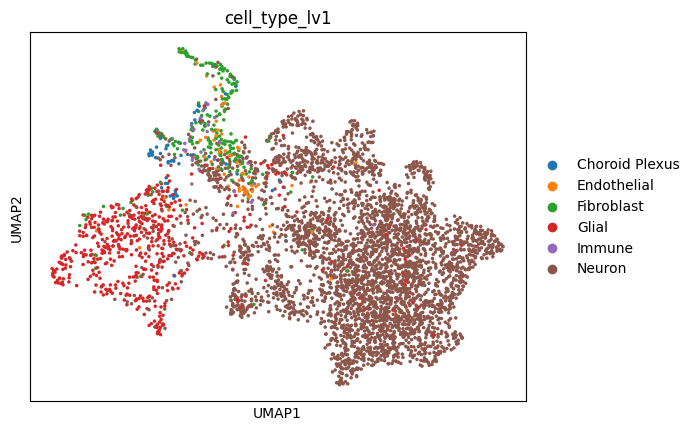

In [91]:
# Visualize on UMAP
sc.pl.umap(lrdata, color=["cell_type_lv1"])

In [133]:
slide_tag

PosixPath('/g/stegle/aalsayah/repos/data/slidatag')

In [92]:
lrdata.write_h5ad(slide_tag / "slidetags/lrdata/SCP2170_wide_anno.h5ad")